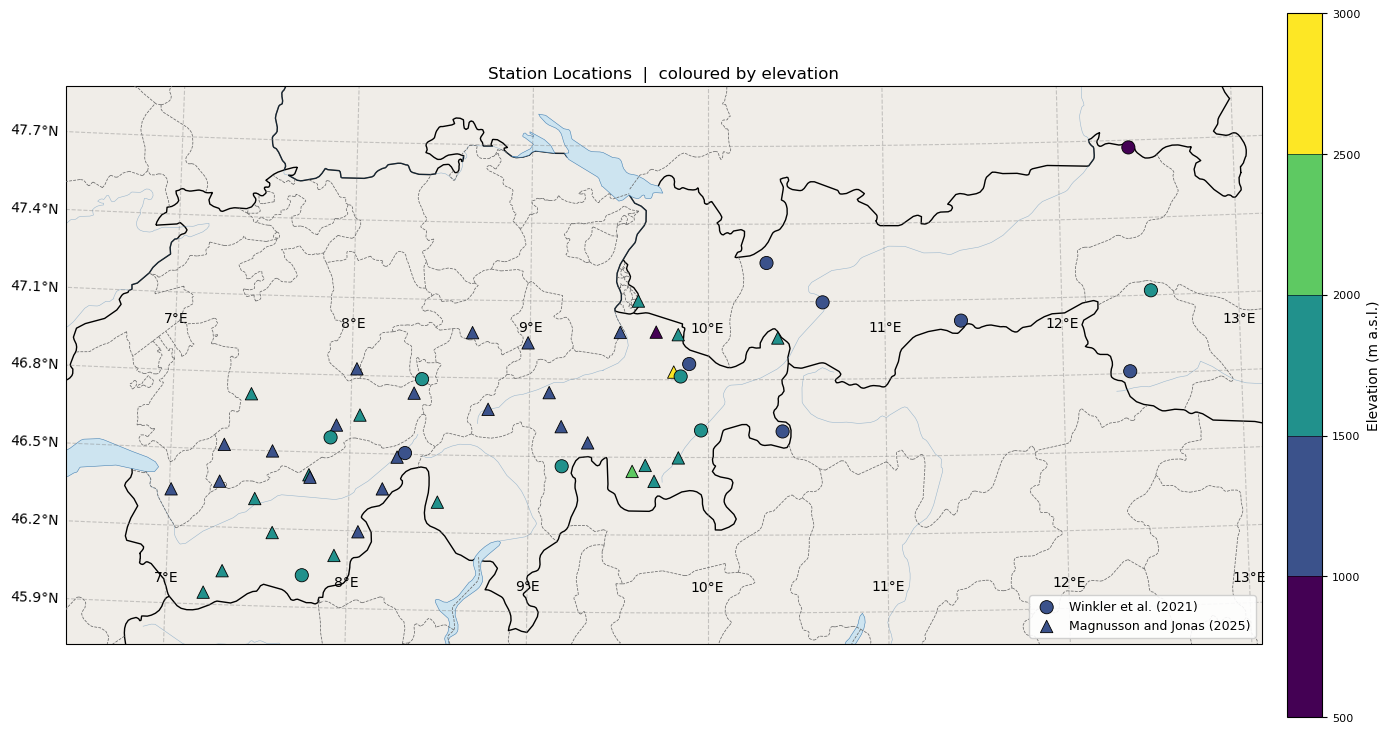

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df       = pd.read_csv("stations_merged.csv")
named_df = df[df["No."] <= 15].copy()
slf_df   = df[df["No."] > 15].copy()

# ── Discrete 500 m elevation bands ───────────────────────────────────────────
vmin     = df["Alt (m)"].min()
vmax     = df["Alt (m)"].max()
bin_size = 500
start    = int((vmin  // bin_size) * bin_size)
end      = int(((vmax + bin_size - 1) // bin_size) * bin_size)
bounds   = list(range(start, end + bin_size, bin_size))

cmap = plt.get_cmap("viridis", len(bounds) - 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N, clip=True)

# ── Map extent ────────────────────────────────────────────────────────────────
all_lon = df["Lon"];  lon_min, lon_max = all_lon.min(), all_lon.max()
all_lat = df["Lat"];  lat_min, lat_max = all_lat.min(), all_lat.max()
lon_pad = (lon_max - lon_min) * 0.10
lat_pad = (lat_max - lat_min) * 0.12

proj = ccrs.LambertConformal(central_longitude=10.0, central_latitude=46.5,
                              standard_parallels=(44, 49))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": proj})
ax.set_extent(
    [lon_min - lon_pad, lon_max + lon_pad,
     lat_min - lat_pad, lat_max + lat_pad],
    crs=ccrs.PlateCarree()
)

# ── Base map features ─────────────────────────────────────────────────────────
ax.add_feature(cfeature.LAND,      facecolor="#f0ede8")
ax.add_feature(cfeature.OCEAN,     facecolor="#cde4f0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=1.0, edgecolor="black")
ax.add_feature(cfeature.RIVERS,    linewidth=0.4, edgecolor="steelblue", alpha=0.5)
ax.add_feature(cfeature.LAKES,     facecolor="#cde4f0", edgecolor="steelblue", linewidth=0.4)

provinces = cfeature.NaturalEarthFeature(
    category="cultural", name="admin_1_states_provinces_lines",
    scale="10m", facecolor="none"
)
ax.add_feature(provinces, edgecolor="dimgrey", linewidth=0.55, linestyle="--", zorder=3)

gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4, color="grey")
gl.top_labels   = False
gl.right_labels = False

# ── Scatter plots ─────────────────────────────────────────────────────────────
ax.scatter(
    named_df["Lon"], named_df["Lat"],
    s=90, marker="o",
    c=named_df["Alt (m)"], cmap=cmap, norm=norm,
    edgecolor="black", linewidth=0.6,
    transform=ccrs.PlateCarree(), label="Winkler et al. (2021)", zorder=6,
)
ax.scatter(
    slf_df["Lon"], slf_df["Lat"],
    s=80, marker="^",
    c=slf_df["Alt (m)"], cmap=cmap, norm=norm,
    edgecolor="black", linewidth=0.6,
    transform=ccrs.PlateCarree(), label="Magnusson and Jonas (2025)", zorder=5,
)

# ── Colorbar (once, after ax exists) ─────────────────────────────────────────
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(
    sm, ax=ax, orientation="vertical", fraction=0.028, pad=0.02,
    ticks=bounds, boundaries=bounds, drawedges=True,
)
cbar.set_label("Elevation (m a.s.l.)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_title("Station Locations  |  coloured by elevation", fontsize=12)
plt.tight_layout()
plt.savefig("stations_map.png", dpi=180, bbox_inches="tight")
plt.show()

In [16]:
df

,No.,Station name,Lon,Lat,Alt (m),#calSWE,#valSWE,Calibration seasons,Validation seasons
0,1,Holzgau,10.333300,47.250000,1100,116,100,7 odd in 1999-2011,7 even in 1998-2010
1,2,Ladis,10.649200,47.096900,1350,83,66,7 odd in 1999-2011,6 even in 1998-2010
2,3,Obernberg,11.429200,47.019400,1360,105,88,7 odd in 1999-2011,7 even in 1998-2010
3,4,Koessen,12.402800,47.671700,590,87,70,7 odd in 1999-2011,6 even in 1998-2010
4,5,Felbertauern,12.505600,47.118100,1650,126,114,7 odd in 1999-2011,7 even in 1998-2010
5,6,Innervillgraten,12.375000,46.808300,1400,96,115,7 odd in 1999-2011,7 even in 1998-2010
6,7,Muerren (SLF.1MR),7.890193,46.558180,1650,37,27,"2009, 2012, 2015, 2017","2006, 2011, 2014, 2016"
7,8,Truebsee,8.395291,46.791210,1780,4,11,2016,"2015, 2017"
8,9,Ulrichen (SLF.4UL),8.308283,46.504610,1350,24,23,"2009, 2013, 2015, 2017","2007, 2011, 2014, 2016"
9,10,Zermatt,7.751165,46.023400,1600,47,76,"1961, 1963",3 even 1960-1964


In [31]:
import pandas as pd
import xarray as xr
import re
import unicodedata
from pathlib import Path

# Load dataset (overwrite ds with the requested file to ensure correct source)
ds = xr.open_dataset("/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/output/merged_nc_files/HS_SWE_dataset.nc")

# Count non-NaN records per station
hs_counts = ds["hs"].count(dim="time").to_series().rename("hs_records")
swe_counts = ds["swe_obs"].count(dim="time").to_series().rename("swe_records")

# Base summary from NetCDF
station_summary_df = pd.concat([hs_counts, swe_counts], axis=1)
station_summary_df.index.name = "station"

# SLF station code -> station name mapping
station_rename = {
    'SLF.1AD': 'Adelboden',
    'SLF.1GA': 'Gadmen',
    'SLF.1GB': 'Grindelwald_Bort',
    'SLF.1GS': 'Gsteig',
    'SLF.1GT': 'Gantrisch',
    'SLF.1LS': 'Leysin',
    'SLF.1MR': 'Muerren',
    'SLF.1SM': 'Saanenmoeser',
    'SLF.1WE': 'Wengen',
    'SLF.2SO': 'Srenberg',
    'SLF.2ST': 'Stoos',
    'SLF.3BR': 'Braunwald',
    'SLF.3MB': 'Malbun',
    'SLF.3MG': 'St_Margrethenberg',
    'SLF.4BN': 'Binn',
    'SLF.4BP': 'Bourg_St_Pierre',
    'SLF.4FY': 'Fionnay',
    'SLF.4GR': 'Grimentz',
    'SLF.4LA': 'Lauchernalp',
    'SLF.4MO': 'Montana',
    'SLF.4MS': 'Muenster',
    'SLF.4SF': 'Saas_Fee',
    'SLF.4SM': 'Simplon_Dorf',
    'SLF.4UL': 'Ulrichen',
    'SLF.4WI': 'Wiler',
    'SLF.5BI': 'Bivio',
    'SLF.5DF': 'Davos_Flueelastr',
    'SLF.5JU': 'Juf',
    'SLF.5OB': 'Obersaxen',
    'SLF.5PU': 'Pusserein',
    'SLF.5SA': 'St_Antoenien',
    'SLF.5SE': 'Sedrun',
    'SLF.5SP': 'Spluegen',
    'SLF.5VA': 'Vals',
    'SLF.5WJ': 'Weisfluh_Joch',
    'SLF.6BG': 'Bosco_Gurin',
    'SLF.6SB': 'San_Bernadino',
    'SLF.7MA': 'Maloja',
    'SLF.7MZ': 'Sankt_Moritz',
    'SLF.7SN': 'Samnaun',
    'SLF.7ZU': 'Zuoz'
}

# Known naming variants seen across datasets
station_aliases = {
    "weissfluhjoch": "weisfluh joch",
    "weissfluh joch": "weisfluh joch"
}

def normalize_station_name(name: str) -> str:
    s = str(name).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = s.replace("_", " ").replace("-", " ").replace(".", " ")
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def first_token(norm_name: str) -> str:
    return norm_name.split(" ")[0] if norm_name else norm_name

# Load station metadata table (prefer stations_map.csv as requested)
stations_map_path = Path("stations_map.csv")
meta_df = pd.read_csv(stations_map_path if stations_map_path.exists() else Path("stations_merged.csv"))

needed_cols = ["Station name", "Alt (m)", "Lon", "Lat"]
missing_cols = [c for c in needed_cols if c not in meta_df.columns]
if missing_cols:
    raise ValueError(f"Missing required metadata columns: {missing_cols}")

# Build a robust lookup by station code and multiple normalized name variants
coords_by_key = {}
slf_code_pattern = re.compile(r"(SLF\.\d[A-Z]{2})")

for _, row in meta_df.iterrows():
    raw_station = str(row["Station name"]).strip()
    value = {"altitude_m": row["Alt (m)"], "lon": row["Lon"], "lat": row["Lat"]}

    keys = set()

    # Raw station string as key
    raw_norm = normalize_station_name(raw_station)
    if raw_norm:
        keys.add(raw_norm)
        keys.add(first_token(raw_norm))

    # Parse patterns like 'Davos Flueelastr. (SLF.5DF)'
    match = slf_code_pattern.search(raw_station)
    code = match.group(1) if match else None
    if code:
        code_norm = normalize_station_name(code)
        keys.add(code_norm)

        name_part = raw_station.split("(")[0].strip()
        if name_part:
            name_norm = normalize_station_name(name_part)
            keys.add(name_norm)
            keys.add(first_token(name_norm))

    # Parse rows that are just station code and map to canonical name
    if raw_station in station_rename:
        mapped_name = station_rename[raw_station]
        mapped_norm = normalize_station_name(mapped_name)
        keys.add(mapped_norm)
        keys.add(first_token(mapped_norm))

    # Add aliases for all collected keys
    alias_keys = {station_aliases[k] for k in list(keys) if k in station_aliases}
    keys.update(alias_keys)

    for k in [k for k in keys if k]:
        if k not in coords_by_key:
            coords_by_key[k] = value

# Attach metadata to each station in the NetCDF summary
meta_rows = []
unmatched_stations = []
for station in station_summary_df.index.astype(str):
    key = normalize_station_name(station)
    key = station_aliases.get(key, key)
    value = coords_by_key.get(key) or coords_by_key.get(first_token(key))
    if value is None:
        value = {"altitude_m": pd.NA, "lon": pd.NA, "lat": pd.NA}
        unmatched_stations.append(station)
    meta_rows.append(value)

meta_for_summary = pd.DataFrame(meta_rows, index=station_summary_df.index)
station_summary_df = pd.concat([station_summary_df, meta_for_summary], axis=1).sort_index()

if unmatched_stations:
    print("Unmatched stations (no coordinates in station metadata file):", sorted(unmatched_stations))

station_summary_df

Unmatched stations (no coordinates in station metadata file): ['kuehtai']


,hs_records,swe_records,altitude_m,lon,lat
station,,,,,
Adelboden,2191,32,1350,7.567861,46.499616
Binn,2191,0,1410,8.186078,46.36463
Bivio,2191,58,1770,9.651027,46.468967
Bosco,2191,0,1530,8.494193,46.317827
Bourg,2191,31,1670,7.208333,45.946093
Braunwald,2191,52,1310,8.988422,46.938127
Davos,3227,70,1560,9.848163,46.81255
Felbertauern,5265,240,1650,12.5056,47.1181
Fionnay,2191,57,1500,7.309099,46.031396


In [32]:
missing_meta = station_summary_df[station_summary_df[["altitude_m", "lon", "lat"]].isna().any(axis=1)]
print("missing stations:", len(missing_meta))
print(sorted(missing_meta.index.astype(str).tolist()))

missing stations: 1
['kuehtai']


In [ ]:
import numpy as np

# Extract SWE observations and remove NaN values
swe_values = ds["swe_obs"].values.flatten()
swe_values = swe_values[~np.isnan(swe_values)]

# Calculate the 2.5th and 97.5th percentiles (95% range)
p2_5 = np.percentile(swe_values, 2.5)
p97_5 = np.percentile(swe_values, 97.5)

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(swe_values, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(p2_5, color='red', linestyle='--', linewidth=2, label=f'2.5th percentile: {p2_5:.1f}')
plt.axvline(p97_5, color='red', linestyle='--', linewidth=2, label=f'97.5th percentile: {p97_5:.1f}')
plt.xlabel('SWE (mm)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of SWE Observations', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"95% of SWE values lie between {p2_5:.1f} mm and {p97_5:.1f} mm")